In [13]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100


In [14]:
node_df: pd.DataFrame
net_df: pd.DataFrame
node_df_2: pd.DataFrame
net_df_2: pd.DataFrame

In [15]:
class NodeOutCol:
    """Many not included here"""
    TS_ABS = "timestamp_absolute"
    MIN_F_TPUT = "min_flow_throughput_ratio"
    MAX_F_TPUT = "max_flow_throughput_ratio"
    AVG_F_YPU_RATIO = "avg_flow_throughput_ratio"
    TOT_TPUT_RATIO = "node_throughput_ratio"
    CURR_PWR_USE = "power_draw_watts"
    EN_USE = "energy_consumed_joule"

In [16]:
class NetOutCol:
    """Many not included here"""
    TS_ABS = "timestamp_absolute"
    NUM_FLOWS = "flows"
    AVG_TPUT_RATIO = "avg_throughput_ratio"
    TOT_TPUT_RATIO = "tot_tput_ratio"
    TOT_TPUT = "tot_tput_mbps"
    CURR_PWR_USE = "power_draw_watt"
    EN_USE = "energy_consumed_joule"

### 1st Output DataFrame

In [17]:
# Path to the folder where the raw network output is.
network_output_folder: str = "../test/100MbpsECMP/networking/"
# ===================================================

node_df = pd.read_parquet(f'{network_output_folder}/node.parquet', engine='pyarrow')
net_df = pd.read_parquet(f'{network_output_folder}/network.parquet', engine='pyarrow')


### 2nd Output DataFrame

In [18]:
# Path to the folder where the raw network output is.
network_output_folder_2: str = "../test/100MbpsOSPF/networking/"
# ===================================================

node_df_2 = pd.read_parquet(f'{network_output_folder_2}/node.parquet', engine='pyarrow')
net_df_2 = pd.read_parquet(f'{network_output_folder_2}/network.parquet', engine='pyarrow')

In [19]:
from functools import reduce

def reduce_granularity(x: list, by: float) -> list:
    newX: list = list()
    size: int = len(x)
    remaining: int = size
    while remaining > by:
        subX = x[remaining-by: remaining]
        avgX = reduce(lambda x, y: x + y, subX) / float(len(subX))
        newX.append(avgX)

        remaining -= by

    return newX

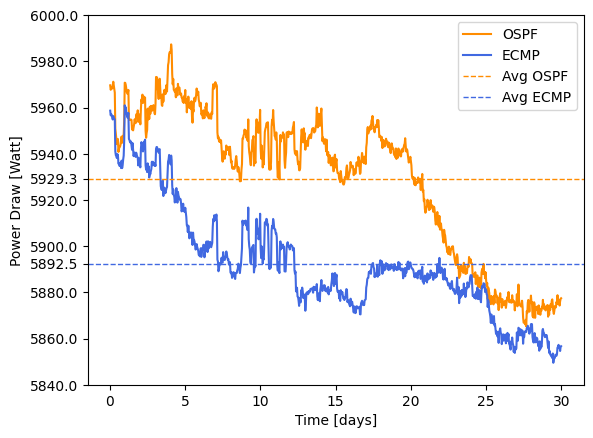

In [20]:
# Create pwr plot
def pwr_plot():
    REDUCE_GRANULARITY_BY: int = 10

    min_ts = net_df[NetOutCol.TS_ABS].min()
    rel_ts = list(map(lambda x: (x - min_ts) / 1000 / 60 / 60 / 24, net_df[NetOutCol.TS_ABS]))
    rel_ts = reduce_granularity(rel_ts, REDUCE_GRANULARITY_BY)
    # pwr_use_1 = reduce_granularity(net_df[NetOutCol.CURR_PWR_USE], REDUCE_GRANULARITY_BY)
    # pwr_use_2 = reduce_granularity(net_df_2[NetOutCol.CURR_PWR_USE], REDUCE_GRANULARITY_BY)

    plt.xlabel("Time [days]")
    plt.ylabel("Power Draw [Watt]")
    plt.plot(rel_ts, pwr_use_2, color="darkorange", label="OSPF")

    plt.plot(rel_ts, pwr_use_1, color="royalblue", label="ECMP")

    plt.axhline(y=np.nanmean(pwr_use_2), color="darkorange", linestyle='--', linewidth=1, label='Avg OSPF')
    plt.axhline(y=np.nanmean(pwr_use_1), color="royalblue", linestyle='--', linewidth=1, label='Avg ECMP')
    plt.yticks(list(plt.yticks()[0]) + [np.nanmean(pwr_use_1)])
    plt.yticks(list(plt.yticks()[0]) + [np.nanmean(pwr_use_2)])
    plt.legend(loc="best")




# min_ts = net_df[NetOutCol.TS_ABS].min()
#     rel_ts = list(map(lambda x: (x - min_ts) / 1000 / 60 / 60 / 24, net_df[NetOutCol.TS_ABS]))
#     rel_ts = reduce_granularity(rel_ts, REDUCE_GRANULARITY_BY)
#     tput = list(map(lambda x: x * 100, net_df[NetOutCol.AVG_TPUT_RATIO]))
#     tput = reduce_granularity(tput, REDUCE_GRANULARITY_BY)

#     tput_2 = list(map(lambda x: x * 100, net_df_2[NetOutCol.AVG_TPUT_RATIO]))
#     tput_2 = reduce_granularity(tput_2, REDUCE_GRANULARITY_BY)
#     plt.plot(rel_ts, tput_2, color="darkorange", label="OSPF")

#     plt.xlabel("Time [days]")
#     plt.ylabel("Throughput [%]")
#     ax = plt.gca()
#     ax.set_ylim([94, 100])
#     # plt.yticks(list(plt.yticks()[0]) + [np.nanmean(tput)])
#     plt.plot(rel_ts, tput, color="royalblue", label="ECMP")
#     plt.legend(loc='best')
#     # plt.axhline(y=np.nanmean(tput), color="purple", linestyle='--', linewidth=2, label='Avg')



pwr_plot()

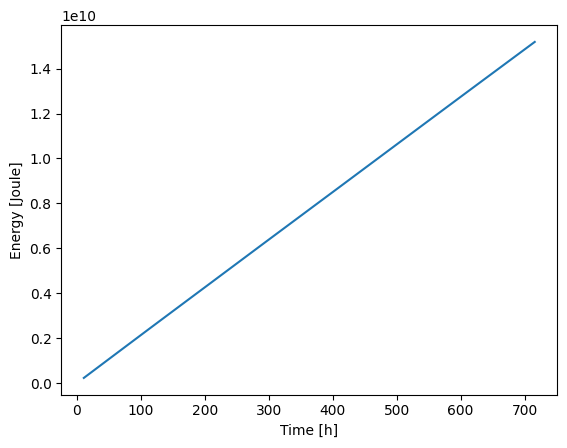

In [21]:
# Create energy plot
def en_plot():
    REDUCE_GRANULARITY_BY: int = 100

    min_ts = net_df[NetOutCol.TS_ABS].min()
    rel_ts = list(map(lambda x: (x - min_ts) / 1000 / 60 / 60, net_df[NetOutCol.TS_ABS]))
    rel_ts = reduce_granularity(rel_ts, REDUCE_GRANULARITY_BY)
    en_use = reduce_granularity(net_df[NetOutCol.EN_USE], REDUCE_GRANULARITY_BY)
    
    plt.xlabel("Time [h]")
    plt.ylabel("Energy [Joule]")
    plt.plot(rel_ts, en_use)

en_plot()

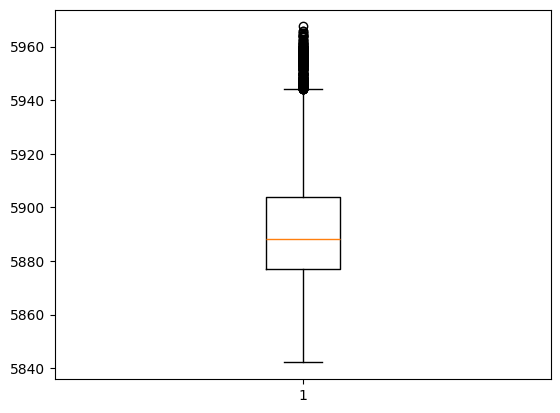

In [22]:
# Create pwr boxplot
def pwr_box_plot():
    plt.boxplot(net_df[NetOutCol.CURR_PWR_USE])


pwr_box_plot()

## Throughput Percentage

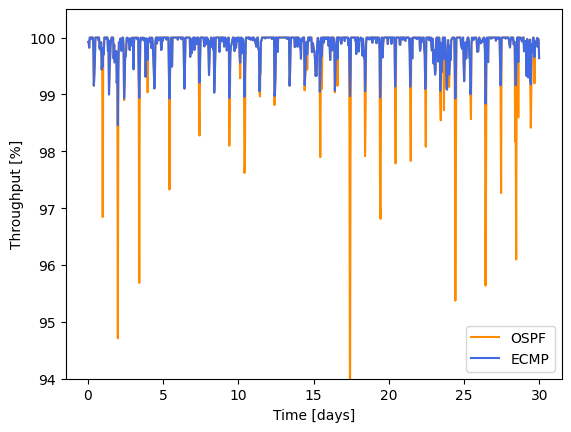

In [23]:


# Create avg tput plot
def avg_tpu_plot():
    REDUCE_GRANULARITY_BY: int = 10

    min_ts = net_df[NetOutCol.TS_ABS].min()
    rel_ts = list(map(lambda x: (x - min_ts) / 1000 / 60 / 60 / 24, net_df[NetOutCol.TS_ABS]))
    rel_ts = reduce_granularity(rel_ts, REDUCE_GRANULARITY_BY)
    tput = list(map(lambda x: x * 100, net_df[NetOutCol.AVG_TPUT_RATIO]))
    tput = reduce_granularity(tput, REDUCE_GRANULARITY_BY)

    tput_2 = list(map(lambda x: x * 100, net_df_2[NetOutCol.AVG_TPUT_RATIO]))
    tput_2 = reduce_granularity(tput_2, REDUCE_GRANULARITY_BY)
    plt.plot(rel_ts, tput_2, color="darkorange", label="OSPF")

    plt.xlabel("Time [days]")
    plt.ylabel("Throughput [%]")
    ax = plt.gca()
    ax.set_ylim([94, 100.5])
    # plt.yticks(list(plt.yticks()[0]) + [np.nanmean(tput)])
    plt.plot(rel_ts, tput, color="royalblue", label="ECMP")
    plt.legend(loc='best')
    # plt.axhline(y=np.nanmean(tput), color="purple", linestyle='--', linewidth=2, label='Avg')





avg_tpu_plot()

## Communication Network Energy Efficency (CNEE)

avg1: 2.320383433030415
avg2: 2.304992985826827
0.006677003920715796


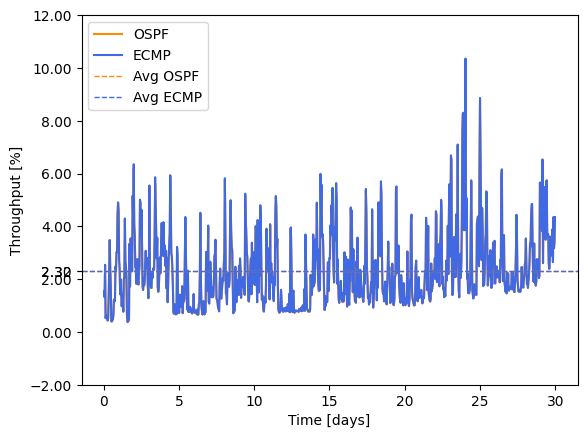

In [24]:
def CNEE_plot():
    REDUCE_GRANULARITY_BY: int = 10

    # x axis
    min_ts = net_df[NetOutCol.TS_ABS].min()
    rel_ts = list(map(lambda x: (x - min_ts) / 1000 / 60 / 60 / 24, net_df[NetOutCol.TS_ABS]))
    rel_ts = reduce_granularity(rel_ts, REDUCE_GRANULARITY_BY)


    tput_1 = list(map(lambda x: x * 100, net_df[NetOutCol.TOT_TPUT]))
    tput_1 = reduce_granularity(tput_1, REDUCE_GRANULARITY_BY)
    pwr_1 = reduce_granularity(net_df[NetOutCol.CURR_PWR_USE], REDUCE_GRANULARITY_BY)
    cnee_1 = [i / j for i, j in zip(tput_1, pwr_1)]

    tput_2 = list(map(lambda x: x * 100, net_df_2[NetOutCol.TOT_TPUT]))
    tput_2 = reduce_granularity(tput_2, REDUCE_GRANULARITY_BY)
    pwr_2 = reduce_granularity(net_df_2[NetOutCol.CURR_PWR_USE], REDUCE_GRANULARITY_BY)
    cnee_2 = [i / j for i, j in zip(tput_2, pwr_2)]


    plt.xlabel("Time [days]")
    plt.ylabel("Throughput [%]")
    plt.plot(rel_ts, cnee_2, color="darkorange", label="OSPF")
    plt.plot(rel_ts, cnee_1, color="royalblue", label="ECMP")


    plt.axhline(y=np.nanmean(cnee_2), color="darkorange", linestyle='--', linewidth=1, label='Avg OSPF')
    plt.axhline(y=np.nanmean(cnee_1), color="royalblue", linestyle='--', linewidth=1, label='Avg ECMP')
    avg1 = np.nanmean(cnee_1) 
    avg2 = np.nanmean(cnee_2) 
    print(f"avg1: {avg1}")
    print(f"avg2: {avg2}")
    print(avg1 / avg2 - 1)
    plt.yticks(list(plt.yticks()[0]) + [np.nanmean(cnee_1)])
    plt.yticks(list(plt.yticks()[0]) + [np.nanmean(cnee_2)])
    plt.legend(loc="best")

    # ax.set_ylim([94, 100])
    # plt.yticks(list(plt.yticks()[0]) + [np.nanmean(tput)])
    plt.legend(loc='best')
    # plt.axhline(y=np.nanmean(tput), color="purple", linestyle='--', linewidth=2, label='Avg')





CNEE_plot()